## Hi! Here is the new playground, go ahead and explore the dataset and find out as many insights as you can before jumping to the ML part! 

In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv('./dataset/housing.csv')
df.head(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB


In [3]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [4]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

##### I identified 207 missing values in the total_bedrooms column. Since each row in this dataset represents a neighborhood rather than a single house, these missing values signify errors or omissions, not a literal zero (a neighborhood of only studios). Replacing these missing values with 0 is dangerous because the model will learn incorrect patterns, such as a large population living with no bedrooms. Because 207 represents a small percentage of our dataset, the first approach that comes to mind is to impute the missing values using the median of the total_bedrooms column. That will be solved when we split the data on train/test to prevent data leakage

##### After analyzing the problematic rows, I observed that the other columns have normal values compared to the rest of the dataset. I based my decision on the median house value, the difference is insignificant, suggesting that the missing values are likely the result of a data collection mistake. Because the number of missing values is small(5%), the missing values are completly random ,probably a mistake in data collection ,and is a numeric type I will use the median value of total_bedrooms to fill in the missing values. This approach is preferable to dropping rows, as it preserves the dataset's size and avoids potential bias from removing data points.

In [5]:
df_cleaned=df.copy()

In [6]:
df_cleaned.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


##### Now that I observed the dataset problems, I will continue with the analysis. At first I will explore some vizualizations and relations using the "explore-pricing.py" script.

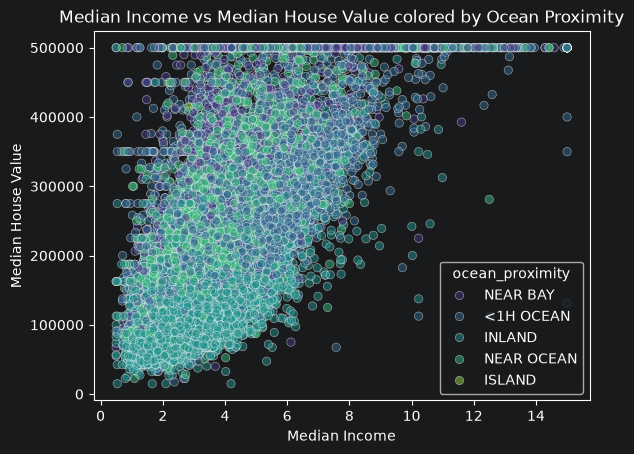

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.scatterplot(x='median_income', y='median_house_value', data=df_cleaned, alpha=0.5, hue='ocean_proximity', palette='viridis', legend='full')
plt.title('Median Income vs Median House Value colored by Ocean Proximity')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.show()

##### I consider this scatter plot to be very relevant because it shows a clear positive correlation between median income and median house value. The diagram shows that as median income increases, the median house value also tends to increase. Additionally, the color coding by ocean proximity reveals that neighborhoods closer to the ocean tend to have higher house values, which is an important insight for our regression model. This suggests that both median income and ocean proximity are significant factors in determining house prices in this dataset. As we can see there is a roof on the datas , the median maximum value is at ~500000 fact that is caused maybe by data collection. I will remove this outliers to analyze the dataset correctly.

In [8]:
df_cleaned = df_cleaned[df_cleaned['median_house_value'] < 500001].copy()

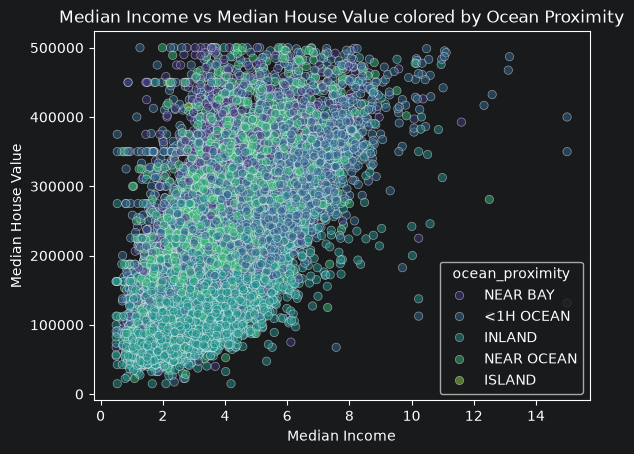

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.scatterplot(x='median_income', y='median_house_value', data=df_cleaned, alpha=0.5, hue='ocean_proximity', palette='viridis', legend='full')
plt.title('Median Income vs Median House Value colored by Ocean Proximity')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.show()

##### As we can see I eliminated the 'wrong' outliers to analyze a cleaner dataset for better results

In [10]:
df_cleaned['rooms_per_household'] = df_cleaned['total_rooms'] / df_cleaned['households']
df_cleaned.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_household
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,6.984127
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,6.238137
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,8.288136
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,5.817352
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,6.281853


In [11]:
df_cleaned['bedrooms_per_rooms']=df_cleaned['total_bedrooms'] / df_cleaned['total_rooms']
df_cleaned

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_household,bedrooms_per_rooms
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,6.984127,0.146591
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,6.238137,0.155797
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,8.288136,0.129516
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,5.817352,0.184458
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,6.281853,0.172096
...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND,5.045455,0.224625
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND,6.114035,0.215208
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND,5.205543,0.215173
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND,5.329513,0.219892


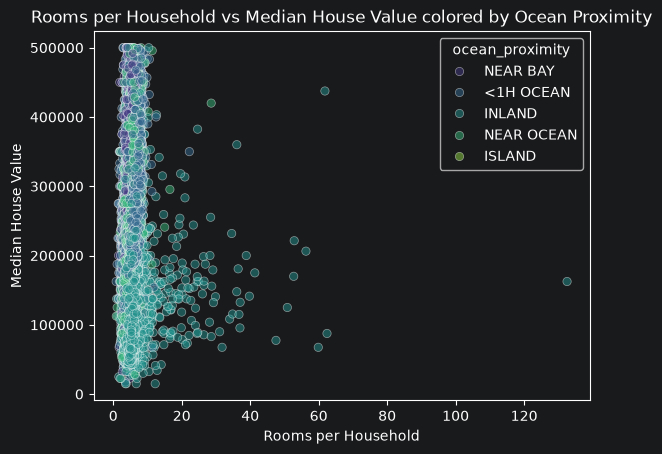

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.scatterplot(x='rooms_per_household', y='median_house_value', data=df_cleaned, alpha=0.5, hue='ocean_proximity', palette='viridis', legend='full')
plt.title('Rooms per Household vs Median House Value colored by Ocean Proximity')
plt.xlabel('Rooms per Household')
plt.ylabel('Median House Value')
plt.show()

##### The scatter plot of rooms per household versus median house value, colored by ocean proximity is not as relevant as the previous one. The relationship between rooms per household and median house value is not as clear or strong as the relationship between median income and median house value. While there may be some correlation, it is not as pronounced, and the data points are more scattered. Additionally, the color coding by ocean proximity does not reveal a significant pattern in this case. Therefore, I would consider this scatter plot to be less relevant for our regression model compared to the previous one.


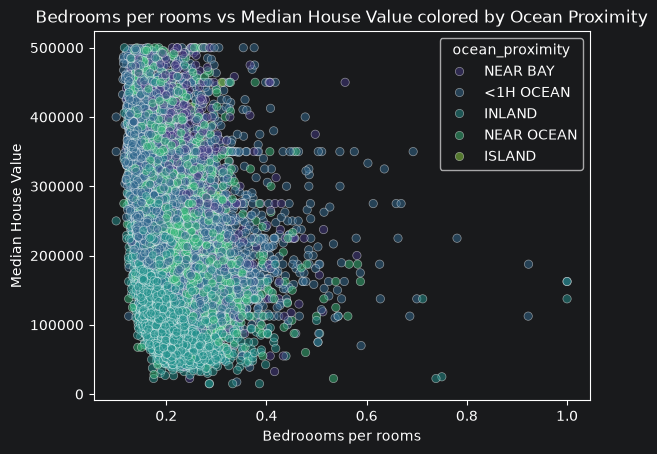

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.scatterplot(x='bedrooms_per_rooms', y='median_house_value', data=df_cleaned, alpha=0.5, hue='ocean_proximity', palette='viridis', legend='full')
plt.title('Bedrooms per rooms vs Median House Value colored by Ocean Proximity')
plt.xlabel('Bedroooms per rooms')
plt.ylabel('Median House Value')
plt.show()

##### The new feature "bedrooms_per_rooms" seems to be relevant for the median house value but this scatter plot is not the best for visualizing his impact on the desired feature. So I will continue the analyze of this feature to decide his importance.

C:\Users\NeagVasileDragos\AppData\Local\Temp\ipykernel_14932\3358665981.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=price_corr.values, y=price_corr.index, palette='viridis')


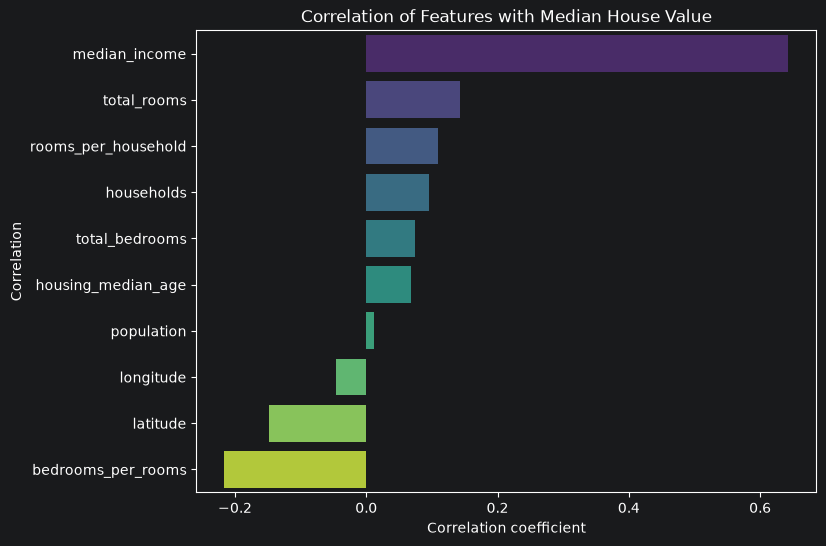

In [14]:
corr = df_cleaned.corr(numeric_only=True)

price_corr = corr['median_house_value'].sort_values(ascending=False)

price_corr = price_corr.drop('median_house_value')

plt.figure(figsize=(8, 6))
sns.barplot(x=price_corr.values, y=price_corr.index, palette='viridis')
plt.title('Correlation of Features with Median House Value')
plt.xlabel('Feature')
plt.ylabel('Correlation')
plt.xlabel('Correlation coefficient')
plt.show()

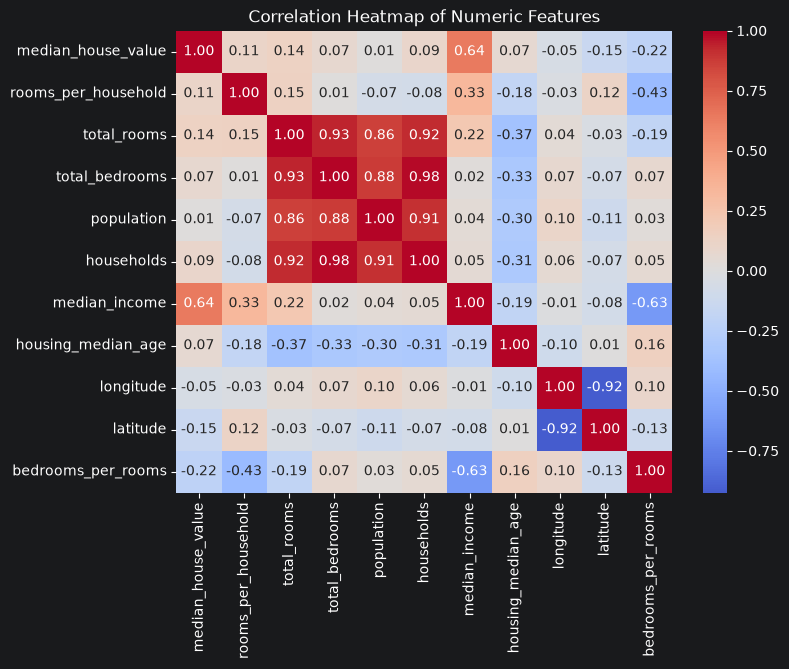

In [15]:
numeric_cols = ['median_house_value', 'rooms_per_household', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income','housing_median_age', 'longitude', 'latitude','bedrooms_per_rooms']

plt.figure(figsize=(8, 6))
sns.heatmap(df_cleaned[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

##### The heatmap diagram shows the correlation between different features and median house value. The features with the highest positive correlation with median house value are median income, rooms per household, and total rooms. This suggests that neighborhoods with higher median incomes, more rooms per household, and more total rooms tend to have higher house values. On the other hand, features like population and households show a negative correlation with median house value, indicating that neighborhoods with larger populations and more households tend to have lower house values. Overall, this heatmap provides valuable insights into the relationships between different features and median house value, which can inform our future model.

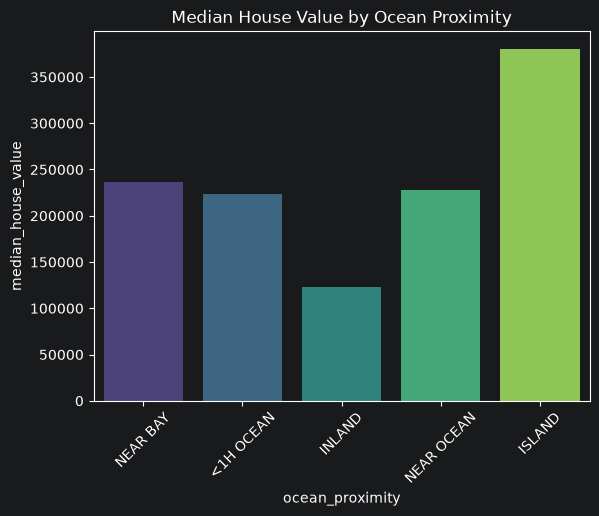

In [16]:


sns.barplot(x='ocean_proximity', y='median_house_value', data=df_cleaned, hue='ocean_proximity',
    palette='viridis',
    errorbar=None,
    legend=False )
plt.title('Median House Value by Ocean Proximity')
plt.xticks(rotation=45)
plt.show()

##### The diagram shows that the median house value varies significantly based on ocean proximity. Island neighborhoods have the highest median house values, followed by neighborhoods that are near the ocean and the bay. In contrast, neighborhoods that are inland have lower median house values. This suggests that ocean proximity is an important factor in determining house prices in this dataset.

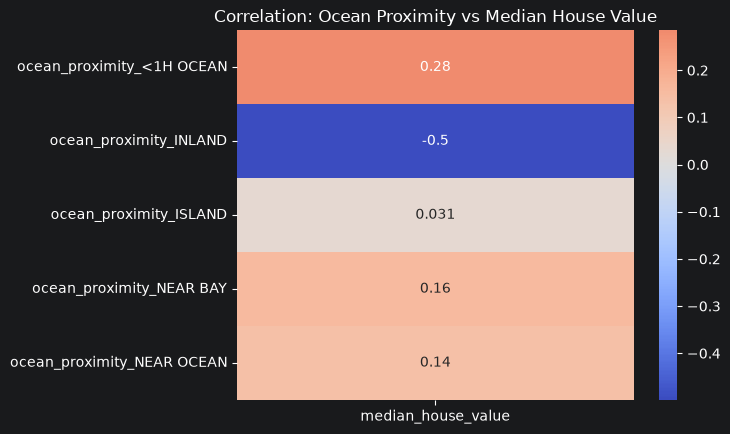

In [17]:

df_encoded_ocean = pd.get_dummies(df_cleaned[['ocean_proximity', 'median_house_value']], drop_first=False)

corr_ocean = df_encoded_ocean.corr()

corr_with_price = corr_ocean[['median_house_value']].drop('median_house_value')

import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(corr_with_price, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation: Ocean Proximity vs Median House Value')
plt.show()

##### The heatmap shows the correlation between ocean proximity and median house value. The diagram indicates how the value evolves based on the proximity to the ocean. The correlation values suggest that neighborhoods that are closer to the ocean tend to have higher median house values, while those that are inland have lower median house values. This reinforces the earlier observation that ocean proximity is a significant factor in determining house prices in this dataset.

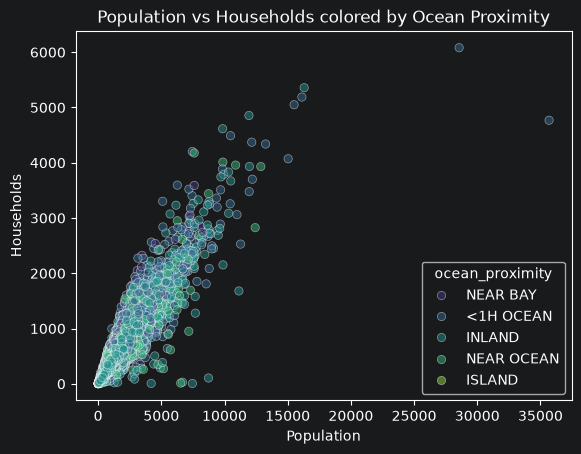

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.scatterplot(x='population', y='households', data=df_cleaned, alpha=0.5, hue='ocean_proximity', palette='viridis', legend='full')
plt.title('Population vs Households colored by Ocean Proximity')
plt.xlabel('Population')
plt.ylabel('Households')
plt.show()

##### The diagram shows the relationship between population and households colored by ocean proximity. The plot indicates that if the population increases in neighborhood , the number of households also tends to increase, which is expected. The color coding by ocean proximity does not reveal a significant pattern in this case. Overall, this scatter plot provides insights into the relationship between population and households, but it may not be as relevant for our regression model compared to other features.

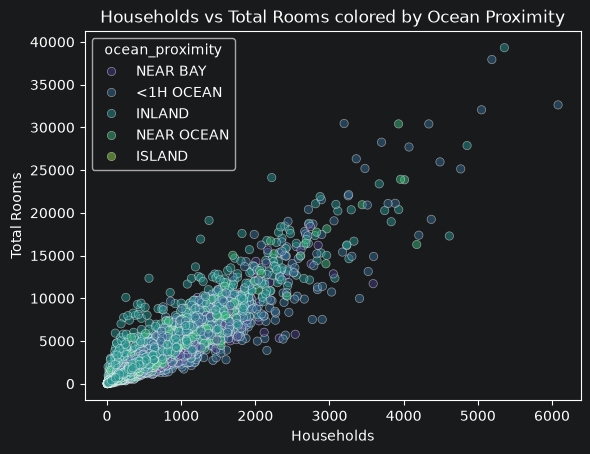

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.scatterplot(x='households', y='total_rooms', data=df_cleaned, alpha=0.5, hue='ocean_proximity', palette='viridis', legend='full')
plt.title('Households vs Total Rooms colored by Ocean Proximity')
plt.xlabel('Households')
plt.ylabel('Total Rooms')
plt.show()

##### The diagram shows the relationship between households and total rooms colored by ocean proximity. The plot indicates that as the number of households increases, the total number of rooms also tends to increase. The same scenario is observed in the previous diagram.

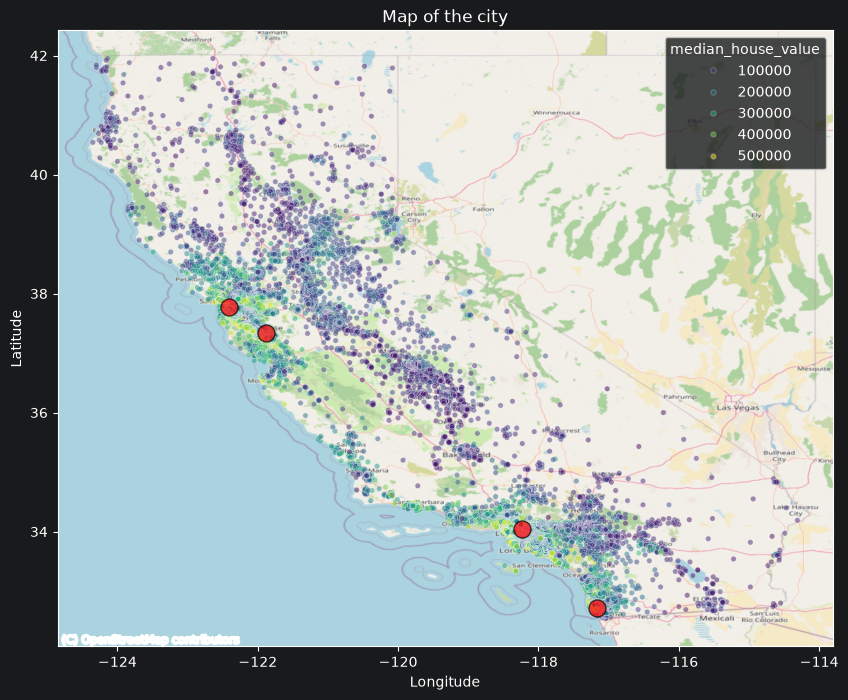

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
import contextily as ctx
plt.figure(figsize=(10, 8))
ans=sns.scatterplot(x='longitude', y='latitude', data=df_cleaned, alpha=0.5, hue='median_house_value', palette='viridis', s=15)
big_cities = {
    'Los Angeles': (-118.24, 34.05),
    'San Francisco': (-122.41, 37.77),
    'San Diego': (-117.16, 32.71),
    'San Jose': (-121.88, 37.33)
}

for city, (lon, lat) in big_cities.items():
    plt.scatter(lon, lat, color='red',s=150,edgecolors='black', label=city, alpha=0.7)

plt.title('Map of the city')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

ctx.add_basemap(ans,crs='EPSG:4326',source=ctx.providers.OpenStreetMap.Mapnik)
plt.show()

##### This diagram shows the geographical distribution of neighborhoods based on their latitude and longitude colored by median house value. The plot shows the big cities nearby the neighborhoods, which are Los Angeles, San Francisco and San Diego (the big red dots on the map). From what I can see, in the proximity of the big cities around the ocean , prices tend to be higher but I have to do a more detalied analysis to confirm this. Overall, this scatter plot provides insights into the geographical distribution of neighborhoods and their median house values, which can inform our future model. And we can see that there are more neighborhoods in the proximity of the big cities.

In [21]:
import numpy as np
distances = pd.DataFrame({
    'Los Angeles': np.sqrt((df_cleaned['longitude'] - -118.24)**2 + (df_cleaned['latitude'] - 34.05)**2),
    'San Francisco': np.sqrt((df_cleaned['longitude'] - -122.41)**2 + (df_cleaned['latitude'] - 37.77)**2),
    'San Diego': np.sqrt((df_cleaned['longitude'] - -117.16)**2 + (df_cleaned['latitude'] - 32.71)**2),
    'San Jose': np.sqrt((df_cleaned['longitude'] - -121.88)**2 + (df_cleaned['latitude'] - 37.33)**2)
    # Here I used the basic distance fromula to calculate the distance from the neighborhoods to big cities even if it's not the best approach because the earth is not flat but for this analysis I think it's enough
})

df_cleaned['closest_cities']= distances.idxmin(axis=1)


In [22]:
df_cleaned

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_household,bedrooms_per_rooms,closest_cities
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,6.984127,0.146591,San Francisco
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,6.238137,0.155797,San Francisco
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,8.288136,0.129516,San Francisco
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,5.817352,0.184458,San Francisco
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,6.281853,0.172096,San Francisco
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND,5.045455,0.224625,San Francisco
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND,6.114035,0.215208,San Francisco
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND,5.205543,0.215173,San Francisco
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND,5.329513,0.219892,San Francisco


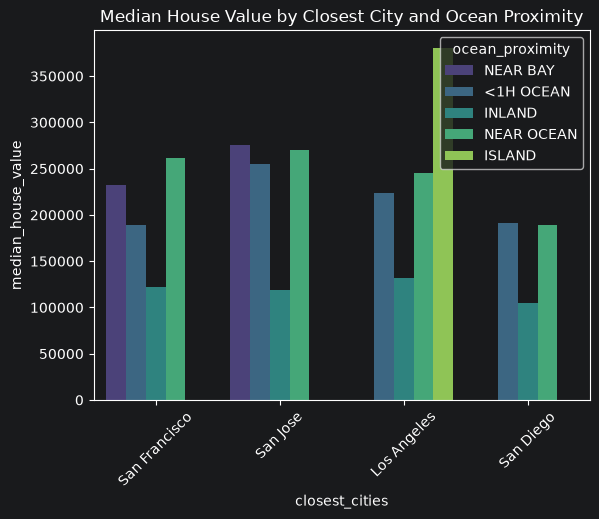

In [23]:


sns.barplot(x='closest_cities', y='median_house_value', data=df_cleaned, hue='ocean_proximity',
    palette='viridis',
    errorbar=None,
    legend=True )
plt.title('Median House Value by Closest City and Ocean Proximity')
plt.xticks(rotation=45)
plt.show()

##### As we can see in diagram , the median house value varies based on the closest city and ocean proximity. In my opinion the closest city is a relevant factor in determining house prices , especially when combined with the ocean proximity.

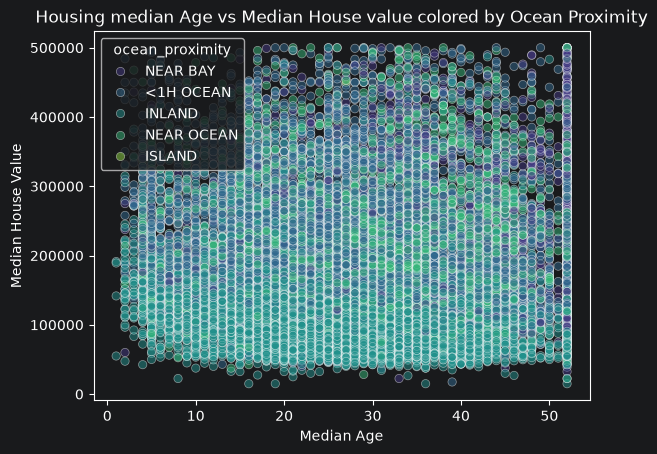

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.scatterplot(x='housing_median_age', y='median_house_value', data=df_cleaned, alpha=0.5, hue='ocean_proximity', palette='viridis', legend='full')
plt.title('Housing median Age vs Median House value colored by Ocean Proximity')
plt.xlabel('Median Age')
plt.ylabel('Median House Value')
plt.show()

##### The diagram shows the median house evolution based on the housing age. The diagram presents very well that every age group has cheap houses , medium value houses and expensive ones. The coloring by ocean proximity shows once again that the house position is very important for the price evolution. The diagram shows us another issue, that there is a lot of outliers on the 50+ age, that may be a data collection mistake that can influence our models.

In [25]:
df_cleaned = df_cleaned[df_cleaned['housing_median_age'] < 52].copy()

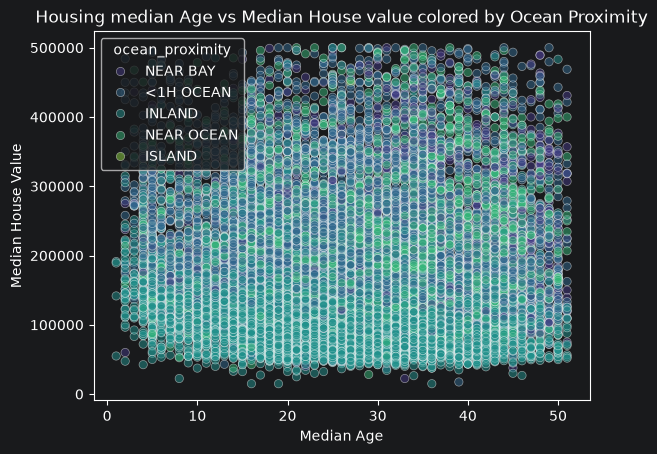

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.scatterplot(x='housing_median_age', y='median_house_value', data=df_cleaned, alpha=0.5, hue='ocean_proximity', palette='viridis', legend='full')
plt.title('Housing median Age vs Median House value colored by Ocean Proximity')
plt.xlabel('Median Age')
plt.ylabel('Median House Value')
plt.show()

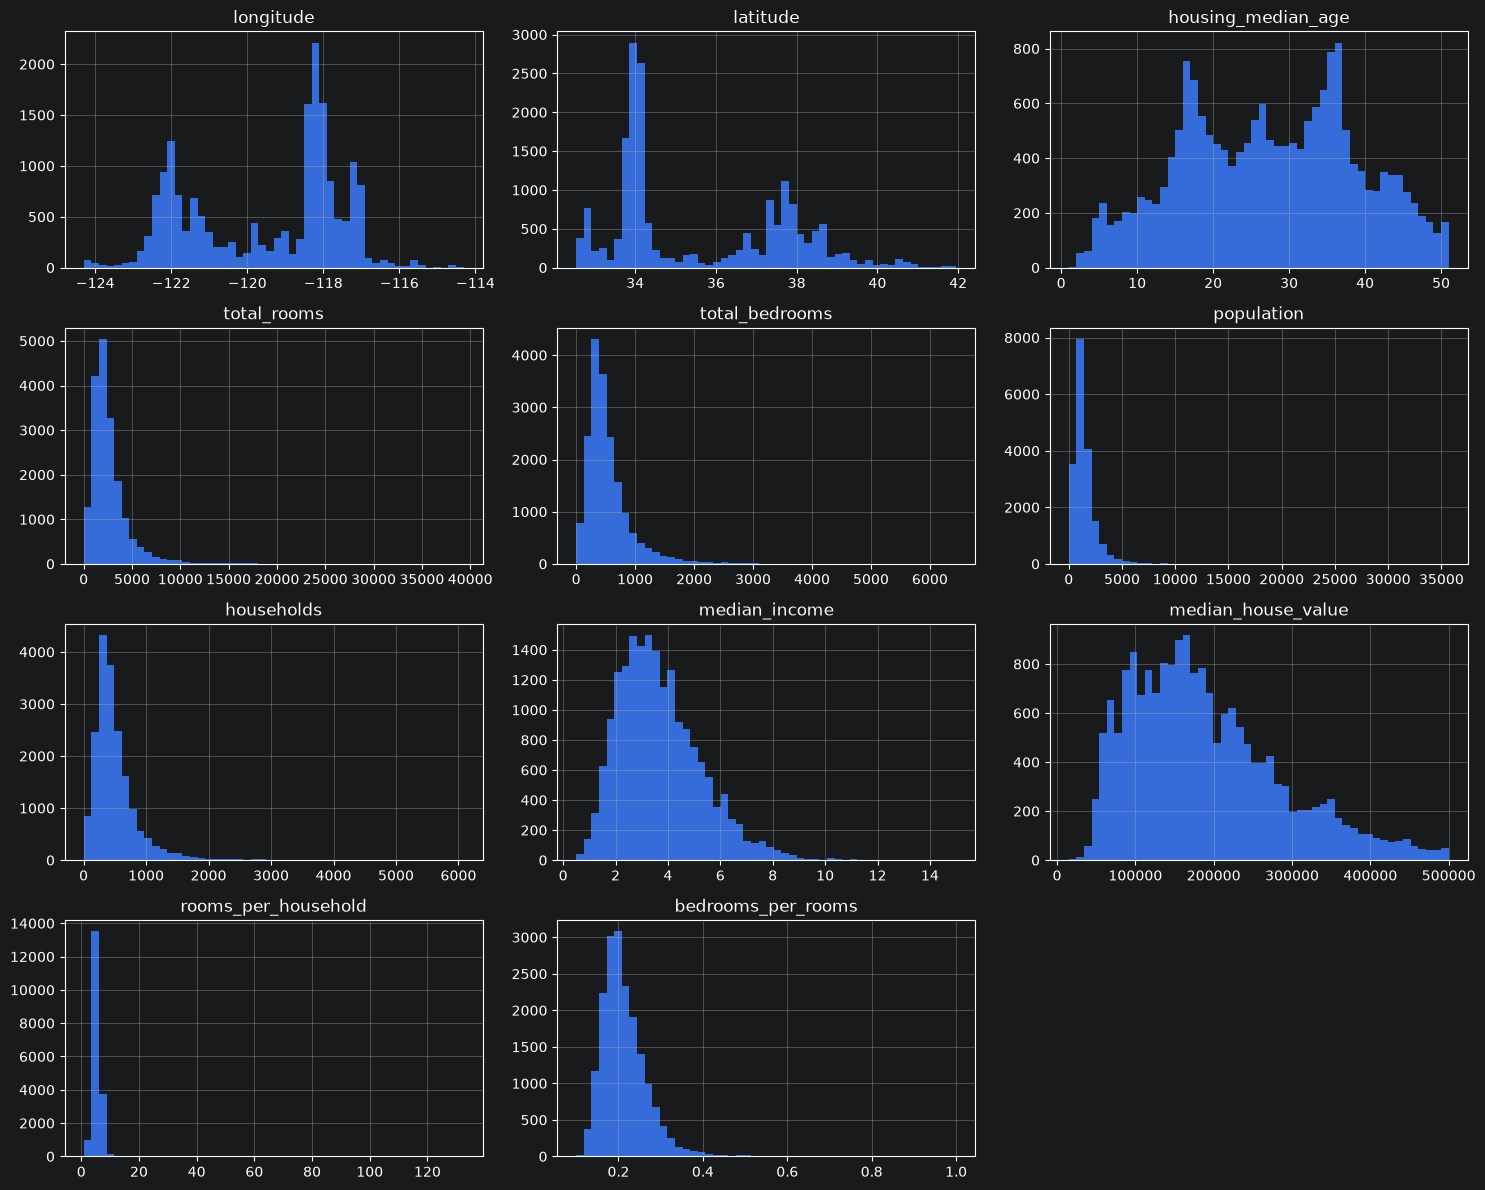

In [27]:
import matplotlib.pyplot as plt

df_cleaned.hist(figsize=(15, 12), bins=50)

plt.tight_layout()
plt.show()

- As we can see from these histograms some features have a small frecuency others a bigger frecuency in the dataset.
- Even though it looks like total_bedrooms may be an useful feature because I already have a more important feature derived from 'total_bedrooms' I chose not to keep this feature for the ML part.
- Because Im dropping the column 'total_bedrooms' the only problem left is to fill the missing values from 'bedrooms_per_room' using the median value from the train set.

In [28]:
#df_encoded = pd.get_dummies(df_cleaned, columns=['ocean_proximity', 'closest_cities'], drop_first=True)

#bool_cols = df_encoded.select_dtypes(include=['bool']).columns
#df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

In [29]:
#df_encoded

- Now that I have my dataset completed and corrected I can start with the ML part.
- But at first I will solve the NULL values problems from the columns : 'total_bedrooms' and 'bedrooms_per_rooms'.



In [30]:
#from sklearn.model_selection import train_test_split
#X = df_encoded.drop(columns=['median_house_value', 'total_rooms', 'total_bedrooms'])
#y = df_encoded['median_house_value']

#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [31]:
#median_bed_per_room = X_train['bedrooms_per_rooms'].median()

#X_train['bedrooms_per_rooms'] = X_train['bedrooms_per_rooms'].fillna(median_bed_per_room)
#X_test['bedrooms_per_rooms'] = X_test['bedrooms_per_rooms'].fillna(median_bed_per_room)



- The commented cells represent my old data preparation without a proper pipeline, even if it will harder to read the code without deleting the old cells I prefer to keep them for a better comparison after I develop the pipeline.

# Data preparation pipeline

In [32]:
# Datset split into train and test (I did this before the pipeline to prevent data leakage)
from sklearn.model_selection import train_test_split

X=df_cleaned.drop(columns=['median_house_value','total_rooms','total_bedrooms'])
y=df_cleaned['median_house_value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [33]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_attribs=['rooms_per_household','population','households','median_income','housing_median_age','longitude','latitude','bedrooms_per_rooms']
cat_attribs=['ocean_proximity','closest_cities']

num_pipeline=Pipeline([('imputer',SimpleImputer(strategy='median')),('std_scaler',StandardScaler())])
full_pipeline=ColumnTransformer([('num',num_pipeline,num_attribs),('cat',OneHotEncoder(handle_unknown='ignore'),cat_attribs)])



- On this cell I created the pipeline , starting with one 'small' pipeline that handle the numerical attribs and then combining the numerical with the categorical
- The numerical pipeline job is to fill the null values from the numerical columns with the median value and to perform standardization on the dataset.
- The full pipeline , combines the num_pipeline with the preparation for the categorical columns
- The preparation for the categorical columns means , applying OneHotEncoding on the columns to make them readable for the models.

In [34]:
X_train_prepared=full_pipeline.fit_transform(X_train)
X_test_prepared=full_pipeline.transform(X_test)

- On this cell I applied the pipeline on the train and test sets
- For the train set we use fit_transform because it learns the parameters(median, mean , std) only from X_train
- For the test set we use only transform because it just applies the learned parameters

1. RandomForestRegressor

In [35]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

rf=RandomForestRegressor(random_state=42)

param_grid= {
    'n_estimators': [100,150,200],
    'max_depth':[10, 20 , None]
}
cv_model=GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)
cv_model.fit(X_train_prepared, y_train)


Fitting 5 folds for each of 9 candidates, totalling 45 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 20, ...], 'n_estimators': [100, 150, ...]}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to de

In [36]:
best_rf = cv_model.best_estimator_
print("best parameters combination:", cv_model.best_params_)

best parameters combination: {'max_depth': 20, 'n_estimators': 200}


In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = best_rf.predict(X_test_prepared)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.3f}")

MAE: 29043.32
RMSE: 43538.47
R²: 0.801


- Based on the performances , the model is acceptable having a: MAE=~29000 , RMSE=~43506 and $R^2$=~80%
- Considering the fact that I used GridSearchCV the problem is with the datas and not the model.
- For improvements I consider adding some new features that can be relevant

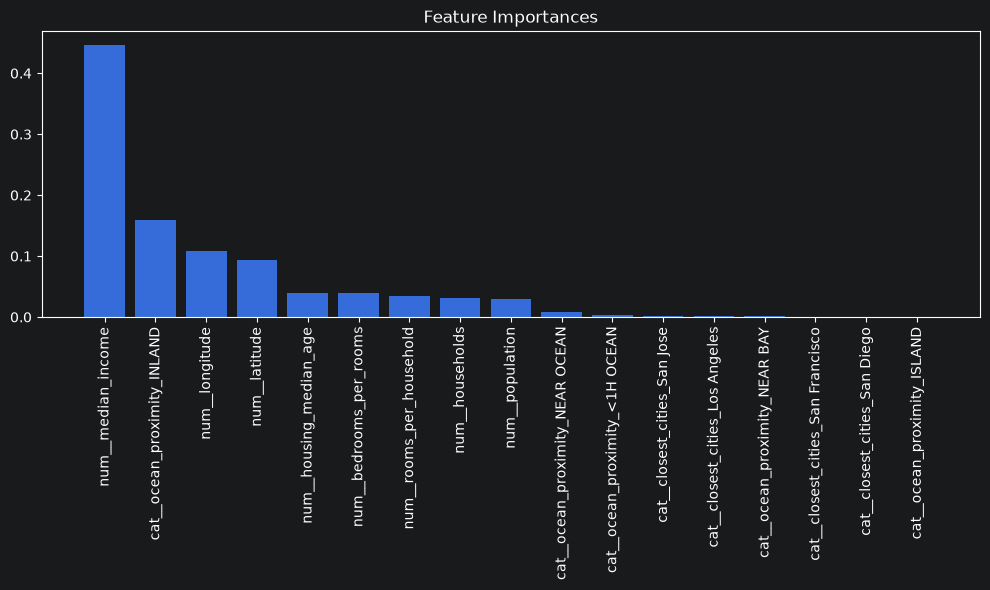

In [38]:
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]
features = full_pipeline.get_feature_names_out()

plt.figure(figsize=(10,6))
plt.title("Feature Importances")
plt.bar(range(len(importances)), importances[indices], align='center')
plt.xticks(range(len(importances)), features[indices], rotation=90)
plt.tight_layout()
plt.show()


- Analyzing the feature importance diagram we can see that how I predicted median_income is a very important feature.
- We can see that some features added by me like ocean_proximity_Island or other ex. are near 0 because of the latitude and longitude weight, the model knows the location already based on these 2 features.

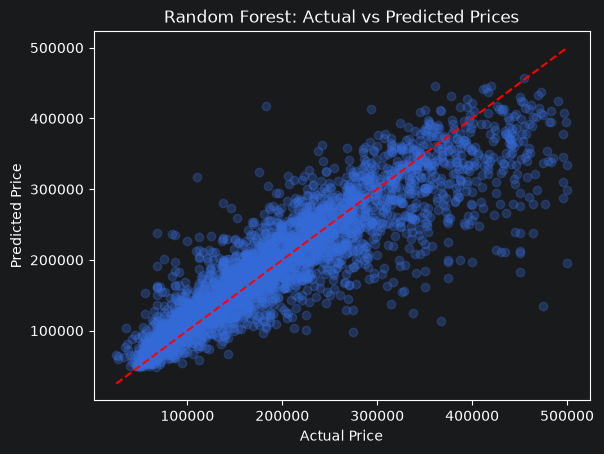

In [39]:
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest: Actual vs Predicted Prices")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

- The regression line diagram shows that the model predicts well the normal values but it has some problems on high value houses.
- To improve the line fit as I said I can work on the features and maybe on the data preprocessing.

2. Linear Regression

In [40]:
#from sklearn.preprocessing import StandardScaler

#scaler=StandardScaler()

#X_train_scaled=scaler.fit_transform(X_train)
#X_test_scaled=scaler.transform(X_test)



In [41]:
from sklearn.linear_model import LinearRegression
lin_reg=LinearRegression()
lin_reg.fit(X_train_prepared, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](17,)","[ 5870.94,-35753.85, 39255.18,...,-22786.72, 10272.94, 9588.65]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.433e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,17
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(15)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](17,)","[189.34,177.05,164.72,..., 1.12, 0. , 0. ]"


In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = lin_reg.predict(X_test_prepared)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.3f}")

MAE: 42430.49
RMSE: 58585.19
R²: 0.640


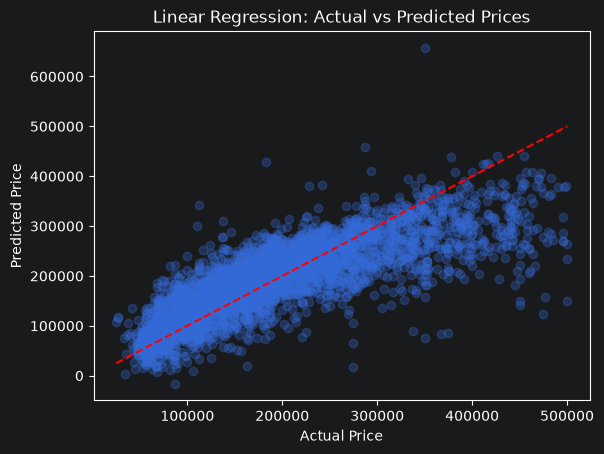

In [43]:
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear Regression: Actual vs Predicted Prices")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

- As expected the linear regression is not as good as the RF model.
- The house pricing evolution is hard to predict using a linear mathematical model.
- The diagram shows that the model performs good on the normal values but on the high value houses it fails.
- The model probably fails because the high value houses can be new houses in cities or old houses in good locations , the price evolution is not a straight line, it depends on many features.
- The major problem is that our model predicts negative prices, so we have to solve this by applying a ln to median house value , doing that the model will work with smaller values and after predicting the price in ln scale we will use the Euler's number to convert the value back to currency.


3. Polynomial Regression

In [44]:
from sklearn.preprocessing import PolynomialFeatures

poly=PolynomialFeatures(degree=2,include_bias=False)
X_train_poly=poly.fit_transform(X_train_prepared)
X_test_poly=poly.transform(X_test_prepared)


In [45]:
model=LinearRegression()
model.fit(X_train_poly, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](170,)","[ 12796.31,-46289.1 , 43363.18,..., -3860.69, 0. ,-20069.15]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,9.201e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,170
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(106)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](170,)","[3186.31,1394.99, 495.66,..., 0. , 0. , 0. ]"


In [46]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test_poly)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.3f}")

MAE: 37151.49
RMSE: 54008.61
R²: 0.694


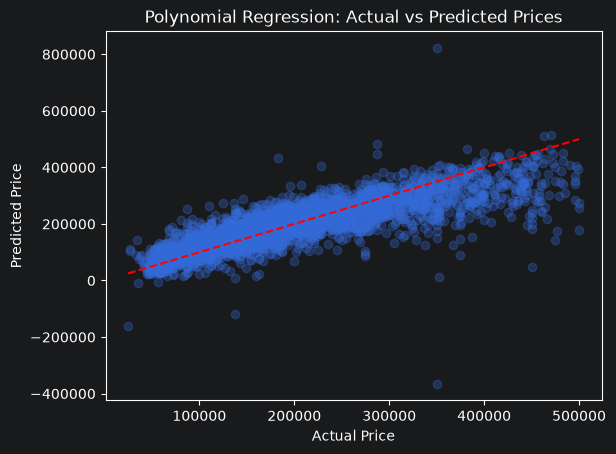

In [47]:
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Polynomial Regression: Actual vs Predicted Prices")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

- We can see that the Polynomial regression obtained better results than the linear one because it solves the biggest problem that we have with linear regression: the strict assumption of linearity.
- Mathematically, while Linear Regression fits a straight line (a first-degree polynomial), Polynomial Regression captures non-linear relationships by introducing higher-degree terms (such as $x^2$ or $x^3$). This allows the model to capture complex patterns in the data that a simple straight line would inevitably miss
- We still have a major problem , our model predicts negative prices wich is impossible so we have to solve this by applying a ln to median house value , doing that the model will work with smaller values and after predicting the price in ln scale we will use the Euler's number to convert the value back to currency.


In [48]:
y_train_log = np.log(y_train)
y_test_log = np.log(y_test)


In [49]:
model.fit(X_train_poly, y_train_log)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](170,)","[ 0.05,-0.22, 0.22,..., 0.07, 0. ,-0.15]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,11.57
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,170
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(106)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](170,)","[3186.31,1394.99, 495.66,..., 0. , 0. , 0. ]"


In [50]:
y_pred_log = model.predict(X_test_poly)
y_pred_real_test = np.exp(y_pred_log)

mae = mean_absolute_error(y_test, y_pred_real_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_real_test))
r2 = r2_score(y_test, y_pred_real_test)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.3f}")

MAE: 35539.87
RMSE: 53010.76
R²: 0.705


In [51]:
y_pred_log = model.predict(X_train_poly)
y_pred_real_train = np.exp(y_pred_log)

mae = mean_absolute_error(y_train, y_pred_real_train)
rmse = np.sqrt(mean_squared_error(y_train, y_pred_real_train))
r2 = r2_score(y_train, y_pred_real_train)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.3f}")

MAE: 34635.30
RMSE: 50698.74
R²: 0.717


- Based on these metrics the polynomial reggresion model does not show overfitting on the train dataset.
- The overfitting may occurs when using a bigger order, in my case the model is only a second order.

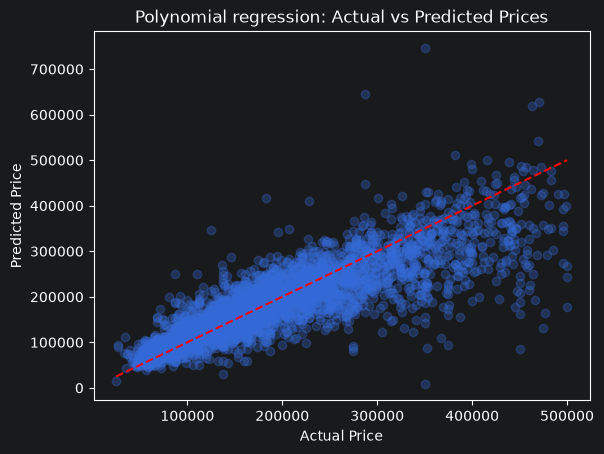

In [52]:
plt.scatter(y_test, y_pred_real_test, alpha=0.3)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Polynomial regression: Actual vs Predicted Prices")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

- Now that I solved the negative values problem we have an ok model that predicts the median house value pretty well even though the datas were not perfect.
- Exactlly like the other 2 models tested , this model works well on normal values but fails on expensive ones.

4. LightGBM

In [53]:
from sklearn.model_selection import GridSearchCV
from lightgbm import LGBMRegressor
lgb_model_GCV=LGBMRegressor(random_state=42)

param_grid={'n_estimators':[100,200,300],'learning_rate':[0.1,0.2,0.3],'num_leaves':[10,20,31]}
grid_search=GridSearchCV(estimator=lgb_model_GCV,param_grid=param_grid,cv=5,scoring='neg_mean_absolute_error',n_jobs=-1)

grid_search.fit(X_train_prepared, y_train)
best_lgb=grid_search.best_estimator_


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000161 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1853
[LightGBM] [Info] Number of data points in the train set: 14857, number of used features: 16
[LightGBM] [Info] Start training from score 189016.651881


In [54]:
y_pred=best_lgb.predict(X_test_prepared)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.3f}")

MAE: 26953.40
RMSE: 39814.12
R²: 0.834


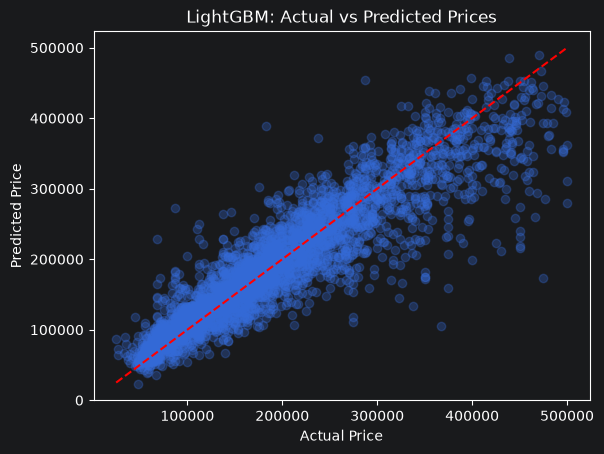

In [55]:
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("LightGBM: Actual vs Predicted Prices")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

- Based on performances the LightGBM model is the best , the model scored the best performances and it's a fast and light model.
- Because of the mathematical concept behind the model , the LGBM predictions were the best yet, performing good even on the outliers , it still has some issues but it's better than the others


# Comparison between the tested models
- The tabel below shows how the tested models performed on the house_pricing dataset

| Model | MAE | RMSE | R² Score |
| :--- | :---: | :---: | :---: |
| LightGBM | 27,123.15 | 40,057.36 | 0.832 |
| Polynomial Regression | 35,539.92 | 53,010.91 | 0.705 |
| Linear Regression | 42,430.49 | 58,585.19 | 0.640 |
| Random Forest Regression | 29,006.15 | 43,506.06 | 0.801 |

- The performance table shows us very well how wich model performed on this dataset.
- As we can see the best metrics are on the Tree-based model , fact that proves the robustness of the models.
- Comparing the linear regression with the polynomial regression, based on the metrics , the polynomial one has better performances because of it's more complex mathematical mechanism.

In [56]:
from sklearn.model_selection import train_test_split
X_numerical= df_cleaned.drop(columns=['closest_cities','ocean_proximity','bedrooms_per_rooms','rooms_per_household','median_house_value'])
y = df_cleaned['median_house_value']

X_train_numerical, X_test_numerical, y_train, y_test = train_test_split(X_numerical, y, test_size=0.2, random_state=42)

In [57]:
median_bed_per_room = X_train_numerical['total_bedrooms'].median()

X_train_numerical['total_bedrooms'] = X_train_numerical['total_bedrooms'].fillna(median_bed_per_room)
X_test_numerical['total_bedrooms'] = X_test_numerical['total_bedrooms'].fillna(median_bed_per_room)

In [58]:
from sklearn.linear_model import LinearRegression
lin_reg=LinearRegression()
lin_reg.fit(X_train_numerical, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[-37714.14,-37557.94, 759.77,..., -28.36, 56.99, 39173.43]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['longitude','latitude','housing_median_age',...,'population','households', 'median_income']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-3.153e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)


In [59]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = lin_reg.predict(X_test_numerical)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.3f}")

MAE: 44720.51
RMSE: 60559.25
R²: 0.615


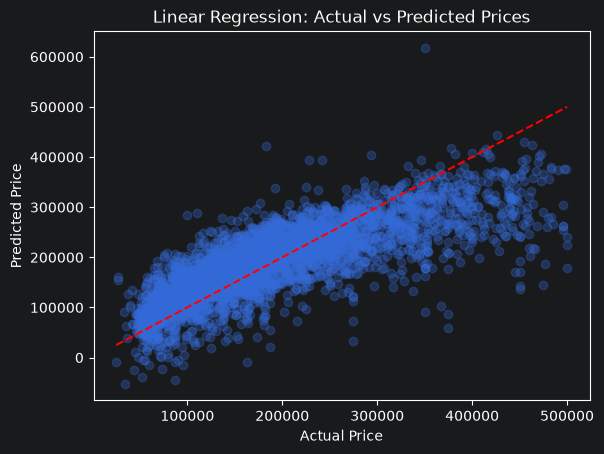

In [60]:
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear Regression: Actual vs Predicted Prices")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

# Comparison between the raw dataset and the prepared dataset on the Linear Regression model
- The experiment on the raw dataset shows us the importance of feature engineering and data preparation
- The $R^2$ of the raw experiment is ~61% and MAE: 44720.51 RMSE: 60559.25 on the prepared dataset $R^2$ is ~64% and MAE: 37152.57 RMSE: 54011.81
- The difference between this metrics shows us how can we improve a model performance using data preparation and feature eng.

# Comparison between the manual data preparation and the pipeline implementation

| Model | MAE (Manual) | MAE (Pipeline) | RMSE (Manual) | RMSE (Pipeline) | R² (Manual) | R² (Pipeline) |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **LightGBM** | 27,123.15 | 26,953.40 | 40,057.36 | 39,814.12 | 0.832 | 0.834 |
| **Random Forest Regression** | 29,006.15 | 29,043.32 | 43,506.06 | 43,538.47 | 0.801 | 0.801 |
| **Polynomial Regression** | 35,539.92 | 35,539.87 | 53,010.91 | 53,010.76 | 0.705 | 0.705 |
| **Linear Regression** | 42,430.49 | 42,430.49 | 58,585.19 | 58,585.19 | 0.640 | 0.640 |

- The tabel shows us that there is a very small difference on some models but the results are almost the same after the pipeline implementation
- The results are almost the same because I already did data preparation on the past version but I didn't use a pipeline
- The only model where we can see a positive difference is the LightGBM. Maybe the difference appears because the LighGBM is a Gradient Boosting model which is sensible to data consistency and because of the SimpleImputer and OneHotEncoder processed the test datas using the exact parameters from training to model performed better .
- The RF model performed a bit worse than before because using the pipeline I totally removed data leakage , and now the model predictions are totally "honest"
- The regressions(linear and polynomial) perfomed exactly the same because before the pipeline I already applied data preparation for the regressions(standardization).